<a href="https://colab.research.google.com/github/noitikbhatt11-sudo/AI-Interview-Proctor/blob/main/AI_Interview_Proctor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Section - 1 (Dataset Preparation and YOLOv8 Model Training)**

In [ ]:
# ----- Install Required Libraries -----
!pip install -q ultralytics
!pip install -q roboflow
!pip install -q opencv-python matplotlib pandas pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.6 MB/s eta 0:00:00


In [ ]:
# ----- Import Required Libraries -----
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("Libraries Imported Successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries Imported Successfully


In [ ]:
# ----- Mount Google Drive -----
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ----- Define Dataset Path -----
dataset_path = "/content/drive/MyDrive/AI_Protoctor"

print("Dataset Path:", dataset_path)

Dataset Path: /content/drive/MyDrive/AI_Protoctor


In [ ]:
# ----- Verify Folder Structure -----
import os
for folder in ["train", "valid", "test"]:

    folder_path = os.path.join(dataset_path, folder)

    print("\n--------------------------------")
    print(folder.upper())
    print("--------------------------------")

    print(os.listdir(folder_path)[:20])


--------------------------------
TRAIN
--------------------------------
['labels', '_annotations.csv', 'images']

--------------------------------
VALID
--------------------------------
['_annotations.csv', 'images', 'labels']

--------------------------------
TEST
--------------------------------
['_annotations.csv', 'images', 'labels']


In [ ]:
# ----- Create Images Folder -----
for folder in ["train", "valid", "test"]:

    folder_path = os.path.join(dataset_path, folder)

    images_path = os.path.join(folder_path, "images")

    os.makedirs(images_path, exist_ok=True)

print("✅ Images folders created.")

✅ Images folders created.


In [ ]:
# ----- Move Images into Images Folder -----
import shutil
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

for folder in ["train", "valid", "test"]:

    folder_path = os.path.join(dataset_path, folder)

    images_path = os.path.join(folder_path, "images")

    for file in os.listdir(folder_path):

        if file.lower().endswith(image_extensions):

            shutil.move(
                os.path.join(folder_path, file),
                os.path.join(images_path, file)
            )

print("✅ Images moved successfully.")

✅ Images moved successfully.


In [ ]:
# ----- Verify Images -----
for folder in ["train", "valid", "test"]:

    images_path = os.path.join(dataset_path, folder, "images")

    total = len(os.listdir(images_path))

    print(f"{folder} images :", total)

train images : 22473
valid images : 1828
test images : 911


In [ ]:
# ----- Display CSV Information -----
import pandas as pd
df = pd.read_csv(
    os.path.join(dataset_path, "train", "_annotations.csv")
)

print(df.head())

print("\nColumns:")
print(df.columns)

print("\nClasses:")
print(df["class"].unique())

                                            filename  width  height  \
0  frame_2150_jpg.rf.d93ac1464b407649af84c2fc5114...    640     640   
1  frame_2150_jpg.rf.d93ac1464b407649af84c2fc5114...    640     640   
2  IMG_6663_jpg.rf.2098611570de01142a5cd04faea2ff...    640     640   
3  final-2_mp4-3108_jpg.rf.aab343317f7e81bd575a32...    640     640   
4  final-2_mp4-3108_jpg.rf.aab343317f7e81bd575a32...    640     640   

        class  xmin  ymin  xmax  ymax  
0      person   137   153   496   636  
1  cell phone   328   511   471   639  
2      laptop   263   184   423   495  
3      person     0     0   122   640  
4      person   265   146   587   640  

Columns:
Index(['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'], dtype='object')

Classes:
['person' 'cell phone' 'laptop' 'book' 'tv' 'headphone']


In [ ]:
# ----- Automatically Create Class IDs -----
classes = sorted(df["class"].unique())

class_map = {
    name: idx
    for idx, name in enumerate(classes)
}

print(class_map)

{'book': 0, 'cell phone': 1, 'headphone': 2, 'laptop': 3, 'person': 4, 'tv': 5}


In [ ]:
# ----- Verify Labels -----
labels_folder = os.path.join(
    dataset_path,
    "train",
    "labels"
)

print("Total label files:", len(os.listdir(labels_folder)))

sample = os.listdir(labels_folder)[0]

print("\nSample Label File:", sample)

with open(os.path.join(labels_folder, sample)) as f:
    print(f.read())

Total label files: 22428

Sample Label File: final-2_mp4-2543_jpg.rf.2fe49c4ece9a12596a95793c76fd1295.txt
1 0.232813 0.694531 0.303125 0.332813
4 0.457031 0.499219 0.564063 0.998437



In [ ]:
# ----- Create "data.yaml" -----
import yaml
import os

# Sort classes by their assigned ID
class_names = [k for k, v in sorted(class_map.items(), key=lambda x: x[1])]

data_yaml = {
    "train": os.path.join(dataset_path, "train", "images"),
    "val": os.path.join(dataset_path, "valid", "images"),
    "test": os.path.join(dataset_path, "test", "images"),
    "nc": len(class_names),
    "names": class_names
}

yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("✅ data.yaml created successfully!")
print("\nLocation:", yaml_path)

✅ data.yaml created successfully!

Location: /content/drive/MyDrive/AI_Protoctor/data.yaml


In [ ]:
# ----- Display "data.yaml" -----
with open(yaml_path, "r") as f:
    print(f.read())

train: /content/drive/MyDrive/AI_Protoctor/train/images
val: /content/drive/MyDrive/AI_Protoctor/valid/images
test: /content/drive/MyDrive/AI_Protoctor/test/images
nc: 6
names:
- book
- cell phone
- headphone
- laptop
- person
- tv



In [ ]:
# ----- Verify Image & Label Counts -----
for folder in ["train", "valid", "test"]:

    img_folder = os.path.join(dataset_path, folder, "images")
    lbl_folder = os.path.join(dataset_path, folder, "labels")

    images = [
        f for f in os.listdir(img_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    labels = [
        f for f in os.listdir(lbl_folder)
        if f.endswith(".txt")
    ]

    print("=" * 50)
    print(folder.upper())
    print("Images :", len(images))
    print("Labels :", len(labels))

TRAIN
Images : 22473
Labels : 22428
VALID
Images : 1828
Labels : 1822
TEST
Images : 911
Labels : 909


In [ ]:
# ----- Check Missing Labels -----
for folder in ["train", "valid", "test"]:

    img_folder = os.path.join(dataset_path, folder, "images")
    lbl_folder = os.path.join(dataset_path, folder, "labels")

    missing = []

    for img in os.listdir(img_folder):

        if img.lower().endswith((".jpg", ".jpeg", ".png")):

            label = os.path.splitext(img)[0] + ".txt"

            if not os.path.exists(os.path.join(lbl_folder, label)):
                missing.append(img)

    print(f"{folder} Missing Labels :", len(missing))

train Missing Labels : 45
valid Missing Labels : 6
test Missing Labels : 2


In [ ]:
# ----- Draw Bounding Boxes -----
import random
import cv2
folder = "train"

image_folder = os.path.join(dataset_path, folder, "images")
label_folder = os.path.join(dataset_path, folder, "labels")

sample = random.choice(os.listdir(image_folder))

image_path = os.path.join(image_folder, sample)

label_path = os.path.join(
    label_folder,
    os.path.splitext(sample)[0] + ".txt"
)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

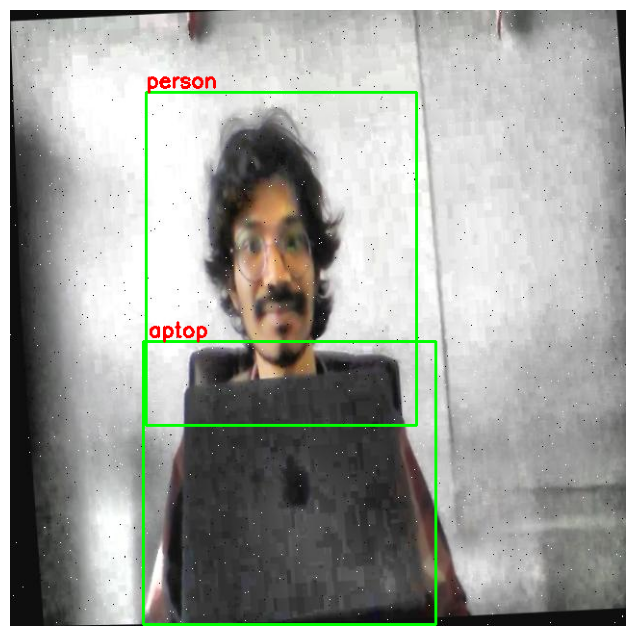

In [ ]:
# ----- Plot Bounding Boxes -----
import matplotlib.pyplot as plt
with open(label_path, "r") as f:

    for line in f.readlines():

        cls, xc, yc, bw, bh = map(float, line.split())

        xc *= w
        yc *= h
        bw *= w
        bh *= h

        xmin = int(xc - bw / 2)
        ymin = int(yc - bh / 2)
        xmax = int(xc + bw / 2)
        ymax = int(yc + bh / 2)

        cv2.rectangle(
            image,
            (xmin, ymin),
            (xmax, ymax),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image,
            class_names[int(cls)],
            (xmin, ymin - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
# ----- Dataset Summary -----
summary = []

for folder in ["train", "valid", "test"]:

    img_folder = os.path.join(dataset_path, folder, "images")
    lbl_folder = os.path.join(dataset_path, folder, "labels")

    images = len([
        f for f in os.listdir(img_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    labels = len([
        f for f in os.listdir(lbl_folder)
        if f.endswith(".txt")
    ])

    summary.append([folder, images, labels])

import pandas as pd

pd.DataFrame(
    summary,
    columns=["Folder", "Images", "Labels"]
)

,Folder,Images,Labels
0,train,22473,22428
1,valid,1828,1822
2,test,911,909


In [ ]:
# ----- Dataset Ready Check -----
print("=" * 50)
print("DATASET READY FOR TRAINING")
print("=" * 50)

print("Classes:", class_names)
print("Total Classes:", len(class_names))
print("data.yaml:", yaml_path)

print("\n✅ Images Organized")
print("✅ Labels Generated")
print("✅ data.yaml Created")
print("✅ Dataset Verified")

print("\n🚀 Ready to Train YOLOv8!")

DATASET READY FOR TRAINING
Classes: ['book', 'cell phone', 'headphone', 'laptop', 'person', 'tv']
Total Classes: 6
data.yaml: /content/drive/MyDrive/AI_Protoctor/data.yaml

✅ Images Organized
✅ Labels Generated
✅ data.yaml Created
✅ Dataset Verified

🚀 Ready to Train YOLOv8!


In [ ]:
# ----- Check GPU -----
import torch

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA Available : True
GPU : Tesla T4


In [ ]:
# ----- Load Pretrained Model -----
!pip install -q ultralytics
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [ ]:
import shutil
import os

small_path = "/content/drive/MyDrive/AI_Protoctor_SMALL"

if os.path.exists(small_path):
    shutil.rmtree(small_path)

print("✅ Old SMALL dataset deleted")

✅ Old SMALL dataset deleted


In [ ]:
import os
import shutil
import random
from pathlib import Path

random.seed(42)

SOURCE = "/content/drive/MyDrive/AI_Protoctor"
DEST = "/content/drive/MyDrive/AI_Protoctor_SMALL"

for split in ["train", "valid", "test"]:

    img_src = Path(SOURCE) / split / "images"
    lbl_src = Path(SOURCE) / split / "labels"

    img_dst = Path(DEST) / split / "images"
    lbl_dst = Path(DEST) / split / "labels"

    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    images = list(img_src.glob("*.*"))

    random.shuffle(images)

    keep = int(len(images) * 0.05)

    print(f"{split}: Total={len(images)}  Keeping={keep}")

    for img in images[:keep]:

        shutil.copy(img, img_dst / img.name)

        label = lbl_src / (img.stem + ".txt")

        if label.exists():
            shutil.copy(label, lbl_dst / label.name)

train: Total=22473  Keeping=1123
valid: Total=1828  Keeping=91
test: Total=911  Keeping=45


In [ ]:
yaml = """
train: /content/drive/MyDrive/AI_Protoctor_SMALL/train/images
val: /content/drive/MyDrive/AI_Protoctor_SMALL/valid/images
test: /content/drive/MyDrive/AI_Protoctor_SMALL/test/images

nc: 6

names:
  - book
  - cell phone
  - headphone
  - laptop
  - person
  - tv
"""

with open("/content/drive/MyDrive/AI_Protoctor_SMALL/data.yaml","w") as f:
    f.write(yaml)

print("✅ data.yaml created")

✅ data.yaml created


In [ ]:
import os

for split in ["train","valid","test"]:
    print(split, len(os.listdir(f"/content/drive/MyDrive/AI_Protoctor_SMALL/{split}/images")))

train 1123
valid 91
test 45


In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/drive/MyDrive/AI_Protoctor_SMALL/data.yaml",
    epochs=2,
    imgsz=160,
    batch=8,
    workers=2,
    cache=True,
    device="cpu",
    project="/content/drive/MyDrive/AI_Protoctor",
    name="Interview_Proctor_Model",
    save=True,
    exist_ok=True
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/AI_Protoctor_SMALL/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=160, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Interview_Proctor_Model, nbs=64, nms=False, opset=None, optimi

In [ ]:
# ----- Validate Model -----
metrics = model.val()

print(metrics)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 18.9±1.7 MB/s, size: 51.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/AI_Protoctor_SMALL/valid/labels.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 15.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.4s
                   all         91        192      0.729      0.307      0.361      0.243
                  book          9          9      0.469      0.111      0.197     0.0499
            cell phone         25         25          1          0     0.0918     0.0487
             headphone          5          5         

In [ ]:
# ----- Show Training Results -----
import os
results_dir = "/content/drive/MyDrive/AI_Protoctor_SMALL/Interview_Proctor_Model"

files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png"
]

for file in files:

    path = os.path.join(results_dir, file)

    if os.path.exists(path):

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title(file)
        plt.axis("off")
        plt.show()

In [ ]:
# -----  -----
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/AI_Protoctor_SMALL/Interview_Proctor_Model"):
    if "best.pt" in files:
        print("Found:", os.path.join(root, "best.pt"))

In [ ]:
# ----- Load Best Model -----
best_model = YOLO(
    "/content/drive/MyDrive/AI_Protoctor/Interview_Proctor_Model/weights/best.pt"
)

In [ ]:
# ----- Test on One Image -----
image_path = "/content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0106_jpg.rf.c9b26effba0c073ee4d76c52c68f312f.jpg"

results = best_model.predict(

    source=image_path,

    conf=0.5,

    save=True,

    show=False
)


image 1/1 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0106_jpg.rf.c9b26effba0c073ee4d76c52c68f312f.jpg: 160x160 1 person, 34.1ms
Speed: 0.8ms preprocess, 34.1ms inference, 1.2ms postprocess per image at shape (1, 3, 160, 160)
Results saved to /content/runs/detect/predict


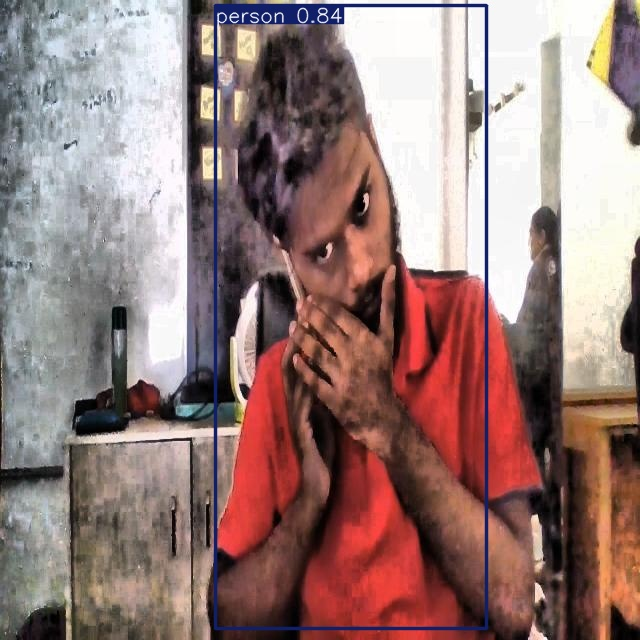

In [ ]:
# ----- Display Prediction -----
from PIL import Image

Image.open(results[0].save_dir + "/" + os.path.basename(image_path))

In [ ]:
# ----- Predict on Entire Test Folder -----
best_model.predict(

    source="/content/drive/MyDrive/AI_Protoctor_SMALL/test/images",

    save=True,

    conf=0.5
)


image 1/45 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0048_jpg.rf.5f66567f2c1ab7b5a05249efce901131.jpg: 160x160 1 person, 44.2ms
image 2/45 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0106_jpg.rf.c9b26effba0c073ee4d76c52c68f312f.jpg: 160x160 1 person, 58.2ms
image 3/45 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0154_jpg.rf.0adf960e474daecf8b30f7058e8d9fd9.jpg: 160x160 2 persons, 41.2ms
image 4/45 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0316_jpg.rf.95ff32312b006fb6e6cbcab53c0ba5d2.jpg: 160x160 1 person, 39.4ms
image 5/45 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0361_jpg.rf.21ad57f06963c92834a0cb7bcb038e78.jpg: 160x160 1 person, 42.3ms
image 6/45 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-0627_jpg.rf.5eadecb9aa4139e7f9fd6892dfb56d81.jpg: 160x160 2 persons, 41.3ms
image 7/45 /content/drive/MyDrive/AI_Protoctor_SMALL/test/images/final-2_mp4-1815_jpg

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'book', 1: 'cell phone', 2: 'headphone', 3: 'laptop', 4: 'person', 5: 'tv'}
 obb: None
 orig_img: array([[[ 65,  62,  58],
         [ 64,  61,  57],
         [ 48,  45,  41],
         ...,
         [208, 253, 255],
         [174, 229, 234],
         [191, 249, 254]],
 
        [[ 67,  64,  60],
         [ 68,  65,  61],
         [ 53,  50,  46],
         ...,
         [198, 245, 249],
         [190, 245, 250],
         [188, 249, 253]],
 
        [[ 59,  56,  52],
         [ 65,  62,  58],
         [ 56,  53,  49],
         ...,
         [188, 236, 240],
         [196, 252, 255],
         [183, 245, 251]],
 
        ...,
 
        [[ 73,  84,  82],
         [ 76,  87,  85],
         [ 78,  86,  85],
         ...,
         [ 15,  18,  39],
         [ 16,  17,  38],
         [ 16,  17,  38]],
 
        [[ 72,  85,  83],
         [ 76,  87

In [ ]:
# ----- Test on Video -----
video_path = "/content/drive/MyDrive/WIN_20260721_02_06_25_Pro.mp4"

best_model.predict(

    source=video_path,

    save=True,

    conf=0.5
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/310) /content/drive/MyDrive/WIN_20260721_02_06_25_Pro.mp4: 96x160 1 person, 30.1ms
video 1/1 (frame 2/310) /content/drive/MyDrive/WIN_20260721_02_06_25_Pro.mp4: 96x160 1 person, 49.0ms
video 1/1 (frame 3/310) /content/drive/MyDrive/WIN_20260721_02_06_25_Pro.mp4: 96x160 1 person, 59.2ms
video 1/1 (frame 4/310) /content/drive/MyDrive/WIN_20260721_02_06_25_Pro.mp4: 96x160 1 person, 47.2ms
video 1/1 (frame 5/310) /content/drive/MyDrive/WIN

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'book', 1: 'cell phone', 2: 'headphone', 3: 'laptop', 4: 'person', 5: 'tv'}
 obb: None
 orig_img: array([[[254, 254, 252],
         [254, 254, 252],
         [254, 254, 252],
         ...,
         [192, 196, 178],
         [192, 196, 178],
         [192, 196, 178]],
 
        [[254, 254, 252],
         [254, 254, 252],
         [254, 254, 252],
         ...,
         [187, 191, 173],
         [185, 189, 171],
         [184, 188, 170]],
 
        [[254, 254, 252],
         [254, 254, 252],
         [254, 254, 252],
         ...,
         [188, 185, 174],
         [185, 182, 171],
         [184, 181, 170]],
 
        ...,
 
        [[252, 254, 246],
         [252, 254, 246],
         [252, 254, 246],
         ...,
         [169, 171, 169],
         [171, 175, 173],
         [171, 175, 173]],
 
        [[252, 254, 246],
         [252, 254

In [ ]:
# ----- Export Model -----
best_model.export(format="onnx")

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/AI_Protoctor/Interview_Proctor_Model/weights/best.pt' with input shape (1, 3, 160, 160) BCHW and output shape(s) (1, 10, 525) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 612ms
Prepared 4 packages in 2.72s
Installed 4 packages in 498ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 4.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 6.8s, 

'/content/drive/MyDrive/AI_Protoctor/Interview_Proctor_Model/weights/best.onnx'

In [ ]:
# ----- Save Model to Drive -----
import shutil

source = "/content/drive/MyDrive/AI_Protoctor/Interview_Proctor_Model/weights/best.pt"

destination = "/content/drive/MyDrive/best.pt"

shutil.copy(source, destination)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
# ----- Final Summary of this Section -----
print("="*60)
print("🎉 TRAINING COMPLETED SUCCESSFULLY")
print("="*60)

print("Model : YOLOv8s")
print("Dataset : AI Interview Proctor")

class_names = model.names
print("Classes:", class_names)

print("\nOutput Folder:")
print("/content/drive/MyDrive/AI_Protoctor/Interview_Proctor_Model")

print("\nBest Model:")
print("/content/drive/MyDrive/best.pt")

print("\nNext Step:")
print("Notebook 2 → AI Interview Proctor")

🎉 TRAINING COMPLETED SUCCESSFULLY
Model : YOLOv8s
Dataset : AI Interview Proctor
Classes: {0: 'book', 1: 'cell phone', 2: 'headphone', 3: 'laptop', 4: 'person', 5: 'tv'}

Output Folder:
/content/drive/MyDrive/AI_Protoctor/Interview_Proctor_Model

Best Model:
/content/drive/MyDrive/best.pt

Next Step:
Notebook 2 → AI Interview Proctor


## **Section - 2 (AI Interview Proctor)**

In [ ]:
# ----- Install Required Libraries -----
!pip -q install ultralytics
!pip -q install mediapipe==0.10.21
!pip -q install opencv-python-headless
!pip -q install pandas
!pip -q install numpy

print("✅ All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 55.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
keras-hub 0.26.0 requires keras>=3.13, which is not installed.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.5.1 which is incompatible.
onnxruntime 1.27.0 requires protobuf>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following d

In [ ]:
# ----- Import Libraries -----
import cv2
import os
import math
import numpy as np
import pandas as pd

import mediapipe as mp

from ultralytics import YOLO

from google.colab import drive
from google.colab import files

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [ ]:
# ----- Load YOLO Model -----
MODEL_PATH = "/content/drive/MyDrive/best.pt"

model = YOLO(MODEL_PATH)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [ ]:
# ----- Print Classes -----
print(model.names)

{0: 'book', 1: 'cell phone', 2: 'headphone', 3: 'laptop', 4: 'person', 5: 'tv'}


In [ ]:
# ----- Upload Interview Video & Read Video Information -----
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

print("Uploaded Video:", video_path)

cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("\n========== Video Information ==========")
print("FPS          :", fps)
print("Width        :", width)
print("Height       :", height)
print("Total Frames :", total_frames)

output_video = "Interview_Proctor_Output.mp4"

writer = cv2.VideoWriter(
    output_video,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

print("\n✅ Video Ready For Processing")

Saving interview.mp4 to interview (1).mp4
Uploaded Video: interview (1).mp4

========== Video Information ==========
FPS          : 10
Width        : 1280
Height       : 720
Total Frames : 259

✅ Video Ready For Processing


In [ ]:
# ----- Initialize MediaPipe Face Mesh -----
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=2,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

mp_drawing = mp.solutions.drawing_utils

drawing_spec = mp_drawing.DrawingSpec(
    thickness=1,
    circle_radius=1
)

print("✅ MediaPipe Face Mesh Initialized")

✅ MediaPipe Face Mesh Initialized


In [ ]:
# ----- Create Variables for Proctoring -----
frame_number = 0

report = []

phone_count = 0
person_count = 0
multiple_person_frames = 0

looking_left = 0
looking_right = 0
looking_up = 0
looking_down = 0

total_faces = 0

print("✅ Variables Initialized")

✅ Variables Initialized


In [ ]:
# ----- YOLO Detection Function -----
def detect_objects(frame):

    results = model(frame, verbose=False)

    detected_objects = []

    for result in results:

        for box in result.boxes:

            cls = int(box.cls[0])
            conf = float(box.conf[0])

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            label = model.names[cls]

            detected_objects.append({
                "class": label,
                "confidence": conf,
                "box": (x1, y1, x2, y2)
            })

    return detected_objects

In [ ]:
# ----- Face Landmark Detection Function -----
def detect_face_mesh(frame):

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = face_mesh.process(rgb)

    return results

In [ ]:
# ----- Start Video Processing Loop -----
while True:

    success, frame = cap.read()

    if not success:
        break

    frame_number += 1

    objects = detect_objects(frame)

    face_results = detect_face_mesh(frame)

    print(f"Processing Frame {frame_number}", end="\r")

print("\n")
print("✅ Initial Frame Processing Completed")



✅ Initial Frame Processing Completed


In [ ]:
# ----- Draw YOLO Detection Results -----
def draw_yolo(frame, objects):

    for obj in objects:

        x1, y1, x2, y2 = obj["box"]

        label = obj["class"]

        confidence = obj["confidence"]

        color = (0,255,0)

        if label == "cell phone":
            color = (0,0,255)

        elif label == "book":
            color = (255,0,0)

        elif label == "person":
            color = (0,255,255)

        cv2.rectangle(frame,
                      (x1,y1),
                      (x2,y2),
                      color,
                      2)

        cv2.putText(frame,
                    f"{label} {confidence:.2f}",
                    (x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    color,
                    2)

    return frame

In [ ]:
# ----- Draw Face Mesh -----
def draw_face_mesh(frame, face_results):

    if face_results.multi_face_landmarks:

        for face_landmarks in face_results.multi_face_landmarks:

            mp_drawing.draw_landmarks(
                frame,
                face_landmarks,
                mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=drawing_spec,
                connection_drawing_spec=drawing_spec
            )

    return frame

In [ ]:
# ----- Count People & Phones -----
def count_objects(objects):

    persons = 0
    phones = 0
    books = 0
    headphones = 0

    for obj in objects:

        if obj["class"] == "person":
            persons += 1

        elif obj["class"] == "cell phone":
            phones += 1

        elif obj["class"] == "book":
            books += 1

        elif obj["class"] == "headphone":
            headphones += 1

    return persons, phones, books, headphones

In [ ]:
# ----- Display Live Proctor Status -----
def draw_status(frame,
                persons,
                phones,
                books,
                headphones):

    cv2.putText(frame,
                f"Persons : {persons}",
                (20,35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0,255,0),
                2)

    cv2.putText(frame,
                f"Phones : {phones}",
                (20,70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0,0,255),
                2)

    cv2.putText(frame,
                f"Books : {books}",
                (20,105),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,0,0),
                2)

    cv2.putText(frame,
                f"Headphones : {headphones}",
                (20,140),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,255,0),
                2)

    return frame

In [ ]:
# ----- Complete Video Processing -----
while True:

    success, frame = cap.read()

    if not success:
        break

    frame_number += 1

    # YOLO Detection
    objects = detect_objects(frame)

    # Face Detection
    face_results = detect_face_mesh(frame)

    # Draw Results
    frame = draw_yolo(frame, objects)

    frame = draw_face_mesh(frame, face_results)

    # Count Objects
    persons, phones, books, headphones = count_objects(objects)

    # Draw Status
    frame = draw_status(frame,
                        persons,
                        phones,
                        books,
                        headphones)

    # Store Report
    report.append({
        "Frame": frame_number,
        "Persons": persons,
        "Phones": phones,
        "Books": books,
        "Headphones": headphones
    })

    writer.write(frame)

print("✅ Video Processing Finished")

✅ Video Processing Finished


In [ ]:
# ----- Head Pose Estimation -----
def estimate_head_pose(face_landmarks, width, height):

    # Nose tip
    nose = face_landmarks.landmark[1]

    # Left & Right Face
    left_face = face_landmarks.landmark[234]
    right_face = face_landmarks.landmark[454]

    # Forehead & Chin
    forehead = face_landmarks.landmark[10]
    chin = face_landmarks.landmark[152]

    nose_x = nose.x
    nose_y = nose.y

    center_x = (left_face.x + right_face.x) / 2
    center_y = (forehead.y + chin.y) / 2

    horizontal = nose_x - center_x
    vertical = nose_y - center_y

    direction = "Center"

    if horizontal < -0.03:
        direction = "Left"

    elif horizontal > 0.03:
        direction = "Right"

    elif vertical < -0.04:
        direction = "Up"

    elif vertical > 0.04:
        direction = "Down"

    return direction

In [ ]:
# ----- Suspicious Activity Detection -----
def detect_suspicious(persons,
                      phones,
                      books,
                      headphones,
                      direction):

    suspicious = []

    if persons > 1:
        suspicious.append("Multiple Persons")

    if phones > 0:
        suspicious.append("Mobile Phone")

    if books > 0:
        suspicious.append("Book Detected")

    if headphones > 0:
        suspicious.append("Headphones")

    if direction != "Center":
        suspicious.append(f"Looking {direction}")

    return suspicious

In [ ]:
# ----- Cheating Score Calculation -----
def cheating_score(events):

    score = 0

    for event in events:

        if event == "Multiple Persons":
            score += 40

        elif event == "Mobile Phone":
            score += 30

        elif event == "Book Detected":
            score += 20

        elif event == "Headphones":
            score += 20

        elif "Looking" in event:
            score += 10

    return min(score,100)

In [ ]:
# Execute the modified save CSV and release resources cell
get_ipython().run_cell_id('d4cd1fd4')

In [ ]:
# Execute the modified interview summary statistics cell
get_ipython().run_cell_id('5b24a54c')

In [ ]:
# ----- Process Frame with AI Logic -----
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=2,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Re-initialize cap and writer, and reset variables for a fresh run
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video stream after re-initialization.")
    report = [] # Ensure report is empty if video can't be opened
    frame_number = 0
else:
    # Reset frame number and report list only if video is successfully opened
    frame_number = 0
    report = []

    # Re-initialize writer
    writer = cv2.VideoWriter(
        output_video,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

while True:

    success, frame = cap.read()

    if not success:
        break

    frame_number += 1

    objects = detect_objects(frame)

    face_results = detect_face_mesh(frame)

    frame = draw_yolo(frame, objects)

    frame = draw_face_mesh(frame, face_results)

    persons, phones, books, headphones = count_objects(objects)

    direction = "Center"

    if face_results.multi_face_landmarks:

        face = face_results.multi_face_landmarks[0]

        direction = estimate_head_pose(
            face,
            width,
            height
        )

    events = detect_suspicious(
        persons,
        phones,
        books,
        headphones,
        direction
    )

    score = cheating_score(events)

    cv2.putText(frame,
                f"Head : {direction}",
                (20,180),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,255,255),
                2)

    cv2.putText(frame,
                f"Score : {score}",
                (20,220),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0,0,255),
                2)

    y = 260

    for event in events:

        cv2.putText(frame,
                    event,
                    (20,y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0,255,255),
                    2)

        y += 30

    report.append({

        "Frame": frame_number,

        "Persons": persons,

        "Phones": phones,

        "Books": books,

        "Headphones": headphones,

        "Head Direction": direction,

        "Score": score,

        "Events": ", ".join(events)

    })

    writer.write(frame)

print("✅ AI Proctor Analysis Completed")

✅ AI Proctor Analysis Completed


In [ ]:
# ----- Save CSV & Release Resources (Integrated) -----
report_df = pd.DataFrame(report)

report_df.to_csv(
    "Interview_Report.csv",
    index=False
)

cap.release()

writer.release()

face_mesh.close()

print("=================================")
print("Interview Analysis Completed")
print("=================================")

print(report_df.head())

print("\nCSV Saved : Interview_Report.csv")

print("Processed Video Saved :", output_video)


Interview Analysis Completed
   Frame  Persons  Phones  Books  Headphones Head Direction  Score Events
0      1        1       0      0           0         Center      0       
1      2        1       0      0           0         Center      0       
2      3        1       0      0           0         Center      0       
3      4        1       0      0           0         Center      0       
4      5        1       0      0           0         Center      0       

CSV Saved : Interview_Report.csv
Processed Video Saved : face_mesh_output.mp4


In [ ]:
# ----- Interview Summary Statistics (Integrated) -----
print("=" * 60)
print("           AI INTERVIEW PROCTOR SUMMARY")
print("=" * 60)

total_frames = len(report_df)

phone_frames = (report_df["Phones"] > 0).sum()
book_frames = (report_df["Books"] > 0).sum()
headphone_frames = (report_df["Headphones"] > 0).sum()
multiple_person_frames = (report_df["Persons"] > 1).sum()

average_score = report_df["Score"].mean()
maximum_score = report_df["Score"].max()

print(f"Total Frames Analysed     : {total_frames}")
print(f"Phone Detected Frames     : {phone_frames}")
print(f"Book Detected Frames      : {book_frames}")
print(f"Headphone Frames          : {headphone_frames}")
print(f"Multiple Person Frames    : {multiple_person_frames}")
print(f"Average Cheating Score    : {average_score:.2f}")
print(f"Maximum Cheating Score    : {maximum_score}")

print("=" * 60)

           AI INTERVIEW PROCTOR SUMMARY
Total Frames Analysed     : 259
Phone Detected Frames     : 0
Book Detected Frames      : 0
Headphone Frames          : 0
Multiple Person Frames    : 0
Average Cheating Score    : 1.89
Maximum Cheating Score    : 10


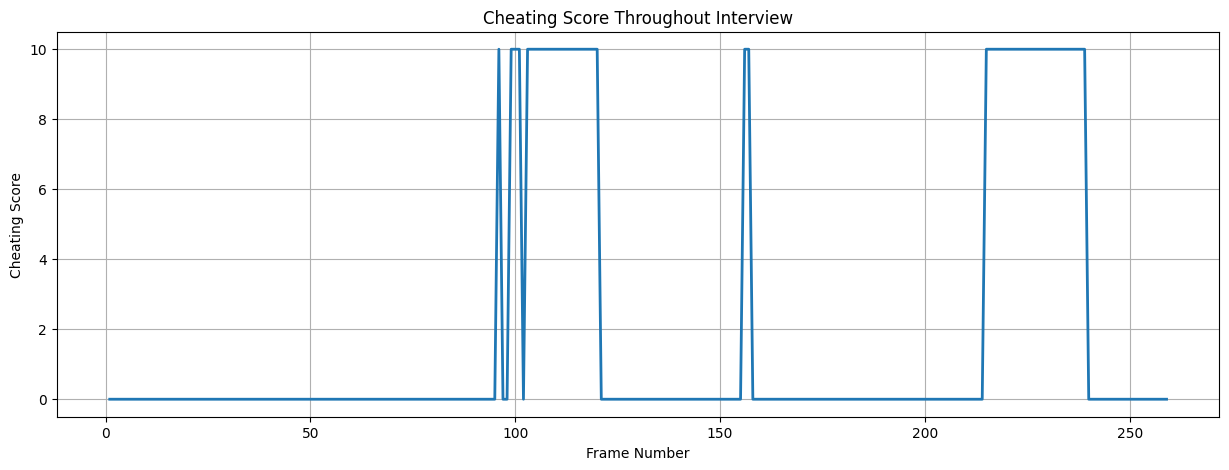

In [ ]:
# ----- Plot Cheating Score Graph -----
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    report_df["Frame"],
    report_df["Score"],
    linewidth=2
)

plt.title("Cheating Score Throughout Interview")

plt.xlabel("Frame Number")

plt.ylabel("Cheating Score")

plt.grid(True)

plt.show()

In [ ]:
# ----- Final Interview Decision -----
average_score = report_df["Score"].mean()

if average_score < 10:

    verdict = "Excellent Candidate"

elif average_score < 25:

    verdict = "Normal Behaviour"

elif average_score < 45:

    verdict = "Slightly Suspicious"

elif average_score < 70:

    verdict = "Highly Suspicious"

else:

    verdict = "Potential Cheating Detected"

print("\n")
print("="*60)
print("FINAL AI INTERVIEW RESULT")
print("="*60)

print("Average Score :", round(average_score,2))
print("Verdict       :", verdict)

print("="*60)



FINAL AI INTERVIEW RESULT
Average Score : 1.89
Verdict       : Excellent Candidate


In [ ]:
# ----- Show Top Suspicious Frames -----
top_frames = report_df.sort_values(
    by="Score",
    ascending=False
).head(10)

print(top_frames)

top_frames.to_csv(
    "Top_Suspicious_Frames.csv",
    index=False
)

print("\nTop suspicious frames saved.")

     Frame  Persons  Phones  Books  Headphones Head Direction  Score  \
218    219        1       0      0           0           Left     10   
119    120        1       0      0           0          Right     10   
226    227        1       0      0           0           Left     10   
225    226        1       0      0           0           Left     10   
224    225        1       0      0           0           Left     10   
223    224        1       0      0           0           Left     10   
222    223        1       0      0           0           Left     10   
221    222        1       0      0           0           Left     10   
220    221        1       0      0           0           Left     10   
219    220        1       0      0           0           Left     10   

            Events  
218   Looking Left  
119  Looking Right  
226   Looking Left  
225   Looking Left  
224   Looking Left  
223   Looking Left  
222   Looking Left  
221   Looking Left  
220   Looking Left

In [ ]:
# ----- Download Results -----
from google.colab import files

print("Downloading Output Video...")
files.download(output_video)

print("Downloading Full Report...")
files.download("Interview_Report.csv")

print("Downloading Suspicious Frames...")
files.download("Top_Suspicious_Frames.csv")

print("\n")
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)
print("Generated Files:")
print("1. Interview_Proctor_Output.mp4")
print("2. Interview_Report.csv")
print("3. Top_Suspicious_Frames.csv")
print("="*60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



PROJECT COMPLETED SUCCESSFULLY
Generated Files:
1. Interview_Proctor_Output.mp4
2. Interview_Report.csv
3. Top_Suspicious_Frames.csv
